In [30]:
import os
import sys
import shutil

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import yaml

from chroma import structure, plotting
from OpenMiChroM.CndbTools import cndbTools
from matplotlib.lines import Line2D
import seaborn as sns
import pandas

from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

plt.style.use("chroma.tex")

# nuclear bodies as beads

# chr1

In [10]:
conditions = ["complete", "nucleolus"]

NUM_REPLICAS = 96
NUM_BEADS = 4980
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

OUTPUT_FOLDER = "/scratch/mm146/Polarization/4_IMR-90_hg38_chr1/7_analysis/contacts/data"

In [11]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [12]:
color_palette

{'complete': '#6abd45',
 'control': '#404040',
 'lamina': '#25C8FA',
 'nucleolus': '#ff0080'}

In [13]:
title = {
    "complete": r"$\in~$lamina",
    "nucleolus": r"$\notin~$lamina",
}

In [15]:
mpl.rcParams["figure.dpi"] = 1000

### Aggregate contact data


due to the size of the dataset, I am running this one with a `sbatch` script

In [ ]:
contacts = {}

for condition in conditions:
    contacts[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        print(f"Processing {condition} replica {replica}")
        with h5py.File(
            f"{OUTPUT_FOLDER}/{condition}/contact-data-replica{replica}.h5",
            "r",
        ) as f:
            for key in f.keys():
                if key not in contacts[condition]:
                    contacts[condition][key] = []
                if key == "contact_probability":
                    contacts[condition][key].append(f[key][()])
                else:
                    contacts[condition][key].append(f[key][::10, :, :])

    contacts[condition]["contact_probability"] = np.mean(
        contacts[condition]["contact_probability"], axis=0
    )
    contacts[condition]["num_contacts_per_bead"] = np.array(
        contacts[condition]["num_contacts_per_bead"]
    )
    contacts[condition]["num_contacts_per_patch"] = np.array(
        contacts[condition]["num_contacts_per_patch"]
    )

In [ ]:
contacts["complete"]["num_contacts_per_patch"].shape

In [ ]:
contacts["complete"]["num_contacts_per_bead"].shape

In [ ]:
contacts["complete"]["contact_probability"].nbytes, contacts[
    "complete"
]["num_contacts_per_bead"].nbytes, contacts["complete"][
    "num_contacts_per_patch"
].nbytes

In [ ]:
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "contact-data-aggregated.h5"), "w"
) as f:
    for condition in contacts.keys():
        grp = f.create_group(condition)
        for key in contacts[condition].keys():
            grp.create_dataset(key, data=contacts[condition][key])

### Plotting contact analyses

In [16]:
contacts = {}
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "contact-data-aggregated.h5"), "r"
) as f:
    for condition in f.keys():
        contacts[condition] = {}
        for key in f[condition].keys():
            contacts[condition][key] = f[condition][key][()]

In [17]:
annotations = np.loadtxt(
    "../../1_inputs/chr1_compartments.txt", dtype=object
)[:, 1]

In [18]:
subcompartments = np.loadtxt(
    "../../1_inputs/chr1_subcompartments.txt", dtype=object
)[:, 1]

#### contact matrix

In [ ]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(7, 1.8),
    sharey=True,
    sharex=True,
    layout="constrained",
    width_ratios=[1, 1, 0.20, 1],
)

for i, condition in enumerate(conditions):
    artist = plotting.PlotContactMap(fig, ax[i])

    im = artist.plot_hic(
        contacts[condition]["contact_probability"],
        scale="linear",
        vmin=0,
        vmax=0.01,
    )
    ax_left = artist.add_compartment_annotations(
        annotations, colors="compartment"
    )
    ax_top = artist.add_compartment_annotations(
        annotations, colors="compartment", loc="top"
    )
    ax_top.set_title(title[condition])

artist.add_colorbar(im)

ax[2].axis("off")

cmap = sns.color_palette("vlag", as_cmap=True)
artist = plotting.PlotContactMap(fig, ax[3])
ax_left = artist.add_compartment_annotations(
    annotations, colors="compartment"
)
ax_top = artist.add_compartment_annotations(
    annotations, colors="compartment", loc="top"
)
im2 = ax[3].imshow(
    contacts["complete"]["contact_probability"]
    / contacts["nucleolus"]["contact_probability"],
    vmin=0,
    vmax=2,
    cmap=cmap,
)
cbar = artist.add_colorbar(im2)
cbar.ax.set_ylabel(
    r"$P_{\in~\text{lamina}} / P_{\notin~\text{lamina}}$"
)

#### total number of contacts per bead

In [19]:
contacts["complete"]["num_contacts_per_bead"].shape

(32, 10000, 4980, 3)

In [20]:
contacts["complete"]["num_contacts_per_bead"].sum(
    axis=3
).min(), contacts["complete"]["num_contacts_per_bead"].sum(
    axis=3
).max()

(0, 26)

In [21]:
contacts["nucleolus"]["num_contacts_per_bead"].sum(
    axis=3
).min(), contacts["nucleolus"]["num_contacts_per_bead"].sum(
    axis=3
).max()

(0, 27)

In [22]:
total_contacts = {
    condition: contacts[condition]["num_contacts_per_bead"][
        :, ::10, :, :
    ].sum(axis=3)
    for condition in conditions
}

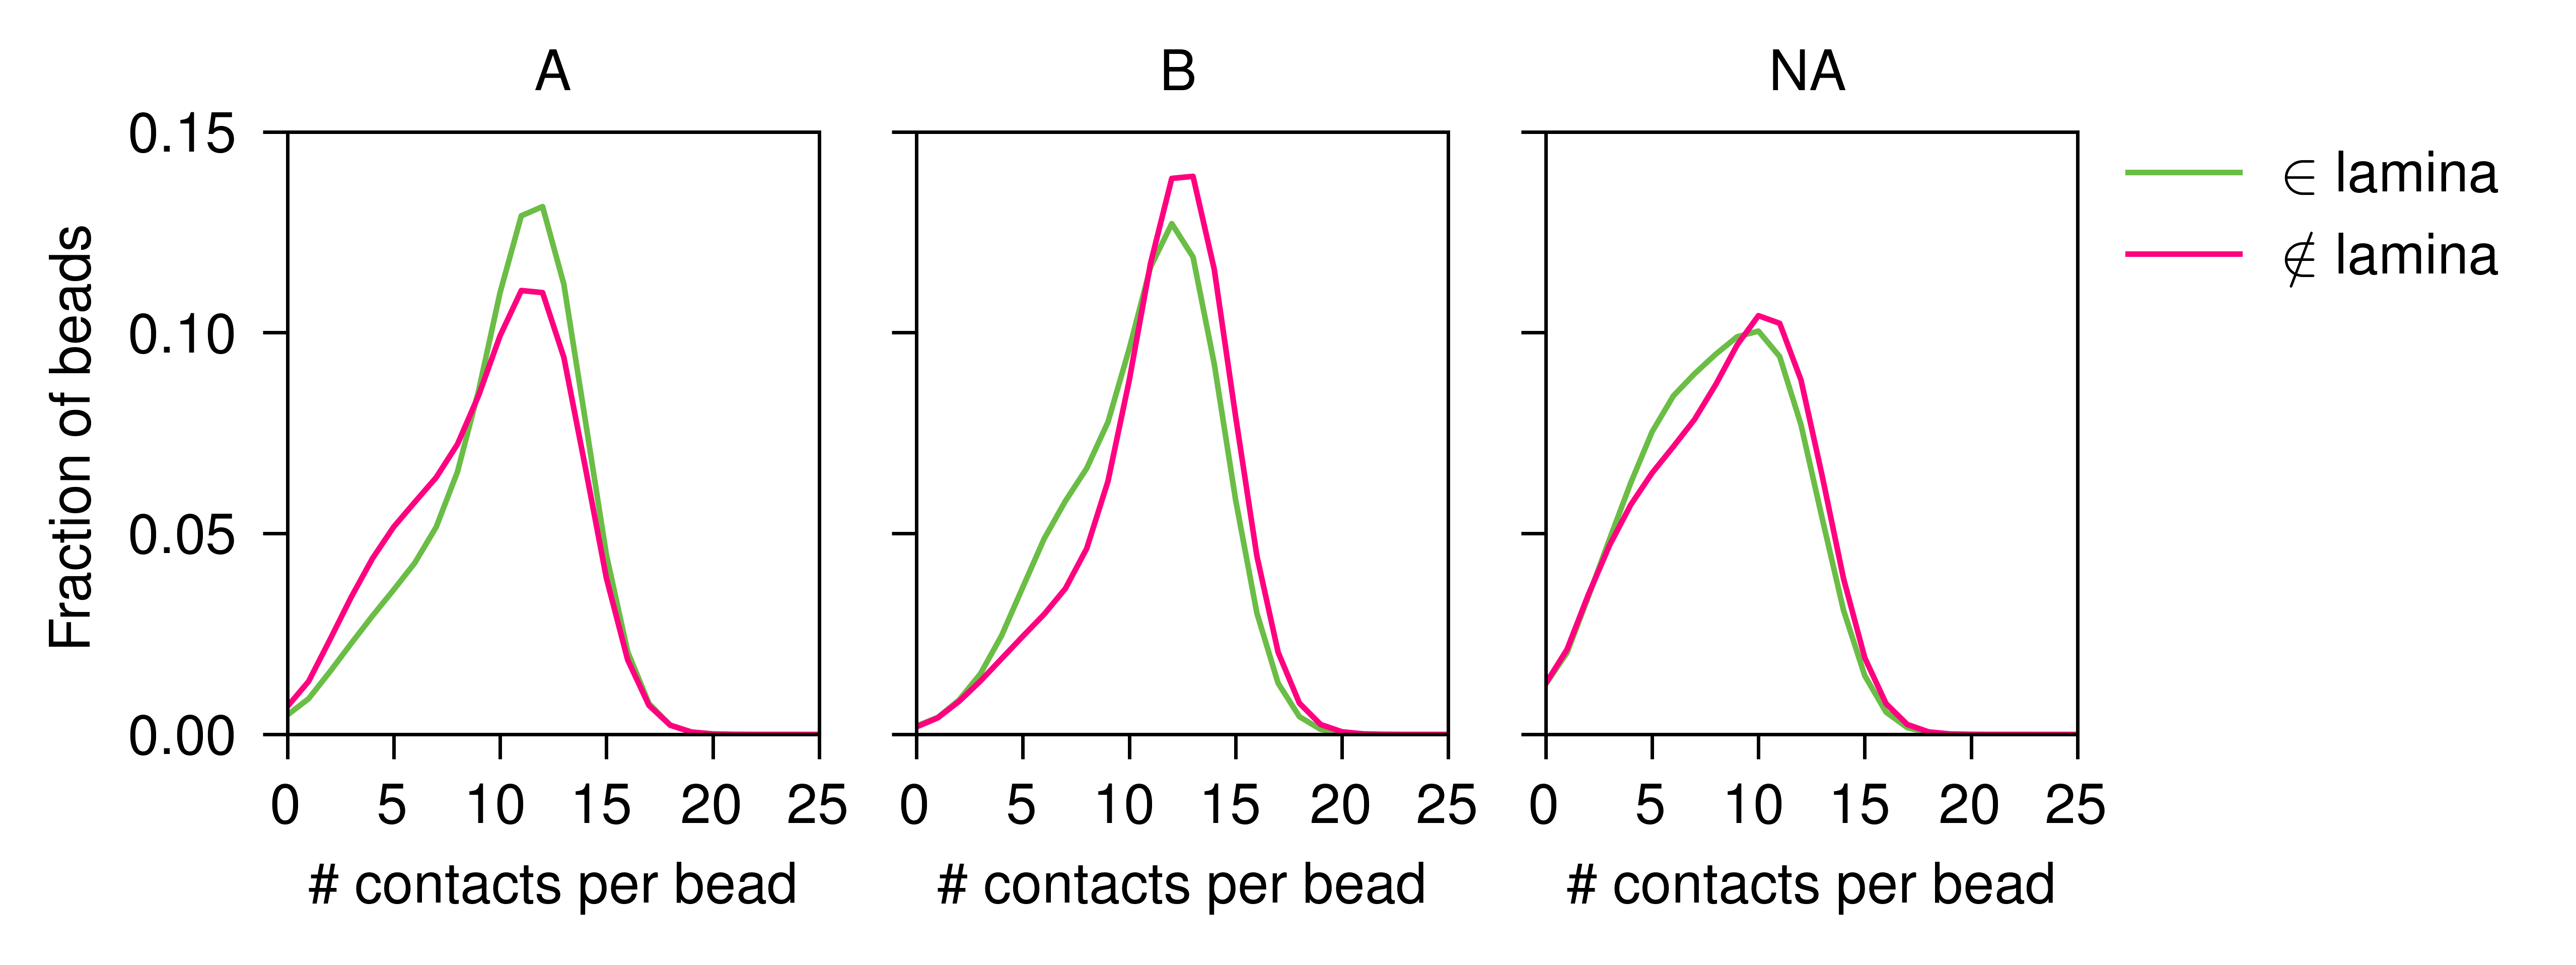

In [35]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(5.0, 1.8),
    layout="constrained",
    sharex=True,
    sharey=True,
)

bins = np.arange(0, 27 + 1, 1)
for i_idx, label in enumerate(["A", "B", "NA"]):

    for condition in conditions:
        data_hist = total_contacts[condition][
            :, :, annotations == label
        ].ravel()

        counts, bins = np.histogram(
            data_hist,
            bins=bins,
            density=False,
            weights=np.ones_like(data_hist) / data_hist.size,
        )

        ax[i_idx].plot(
            bins[:-1],
            counts,
            label=title[condition],
            color=color_palette[condition],
        )

    ax[i_idx].set_title(f"{label}", fontsize=8)
    ax[i_idx].set_xlabel(r"\# contacts per bead")
    ax[i_idx].set_xticks([0, 5, 10, 15, 20, 25])
    ax[i_idx].set_xlim(bins[0], 25)
    ax[i_idx].set_ylim(0, 0.15)
ax[0].set_ylabel("Fraction of beads")
ax[-1].legend(
    frameon=False, loc="upper left", bbox_to_anchor=(1, 1.05)
)

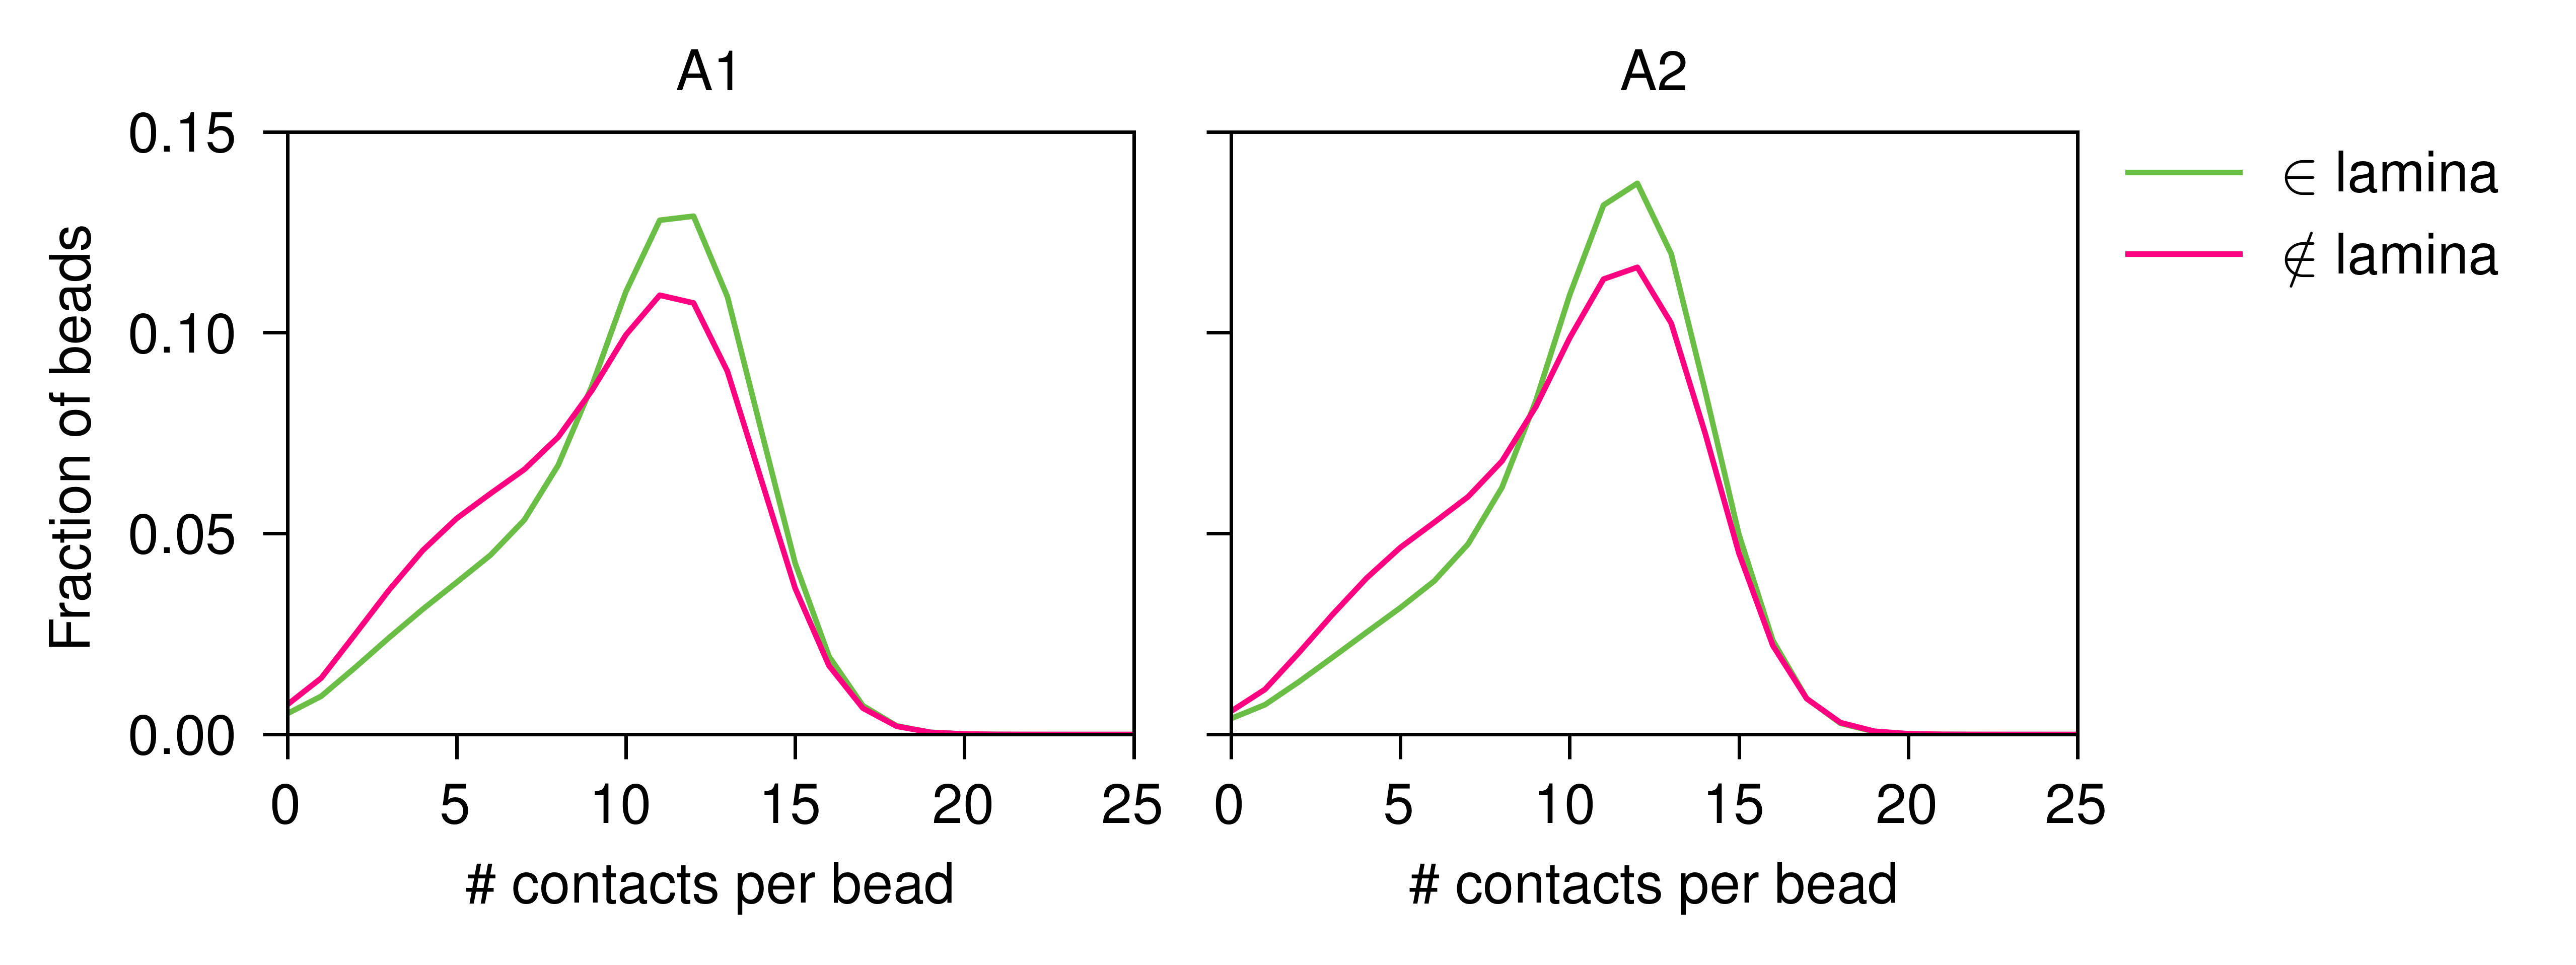

In [24]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(5.0, 1.8),
    layout="constrained",
    sharex=True,
    sharey=True,
)

bins = np.arange(0, 27 + 1, 1)
for i_idx, label in enumerate(["A1", "A2"]):

    for condition in conditions:
        data_hist = total_contacts[condition][
            :, :, subcompartments == label
        ].ravel()

        counts, bins = np.histogram(
            data_hist,
            bins=bins,
            density=False,
            weights=np.ones_like(data_hist) / data_hist.size,
        )

        ax[i_idx].plot(
            bins[:-1],
            counts,
            label=title[condition],
            color=color_palette[condition],
        )

    ax[i_idx].set_title(f"{label}", fontsize=8)
    ax[i_idx].set_xlabel(r"\# contacts per bead")
    ax[i_idx].set_xticks([0, 5, 10, 15, 20, 25])
    ax[i_idx].set_xlim(bins[0], 25)
    ax[i_idx].set_ylim(0, 0.15)
ax[0].set_ylabel("Fraction of beads")
ax[-1].legend(
    frameon=False, loc="upper left", bbox_to_anchor=(1, 1.05)
)

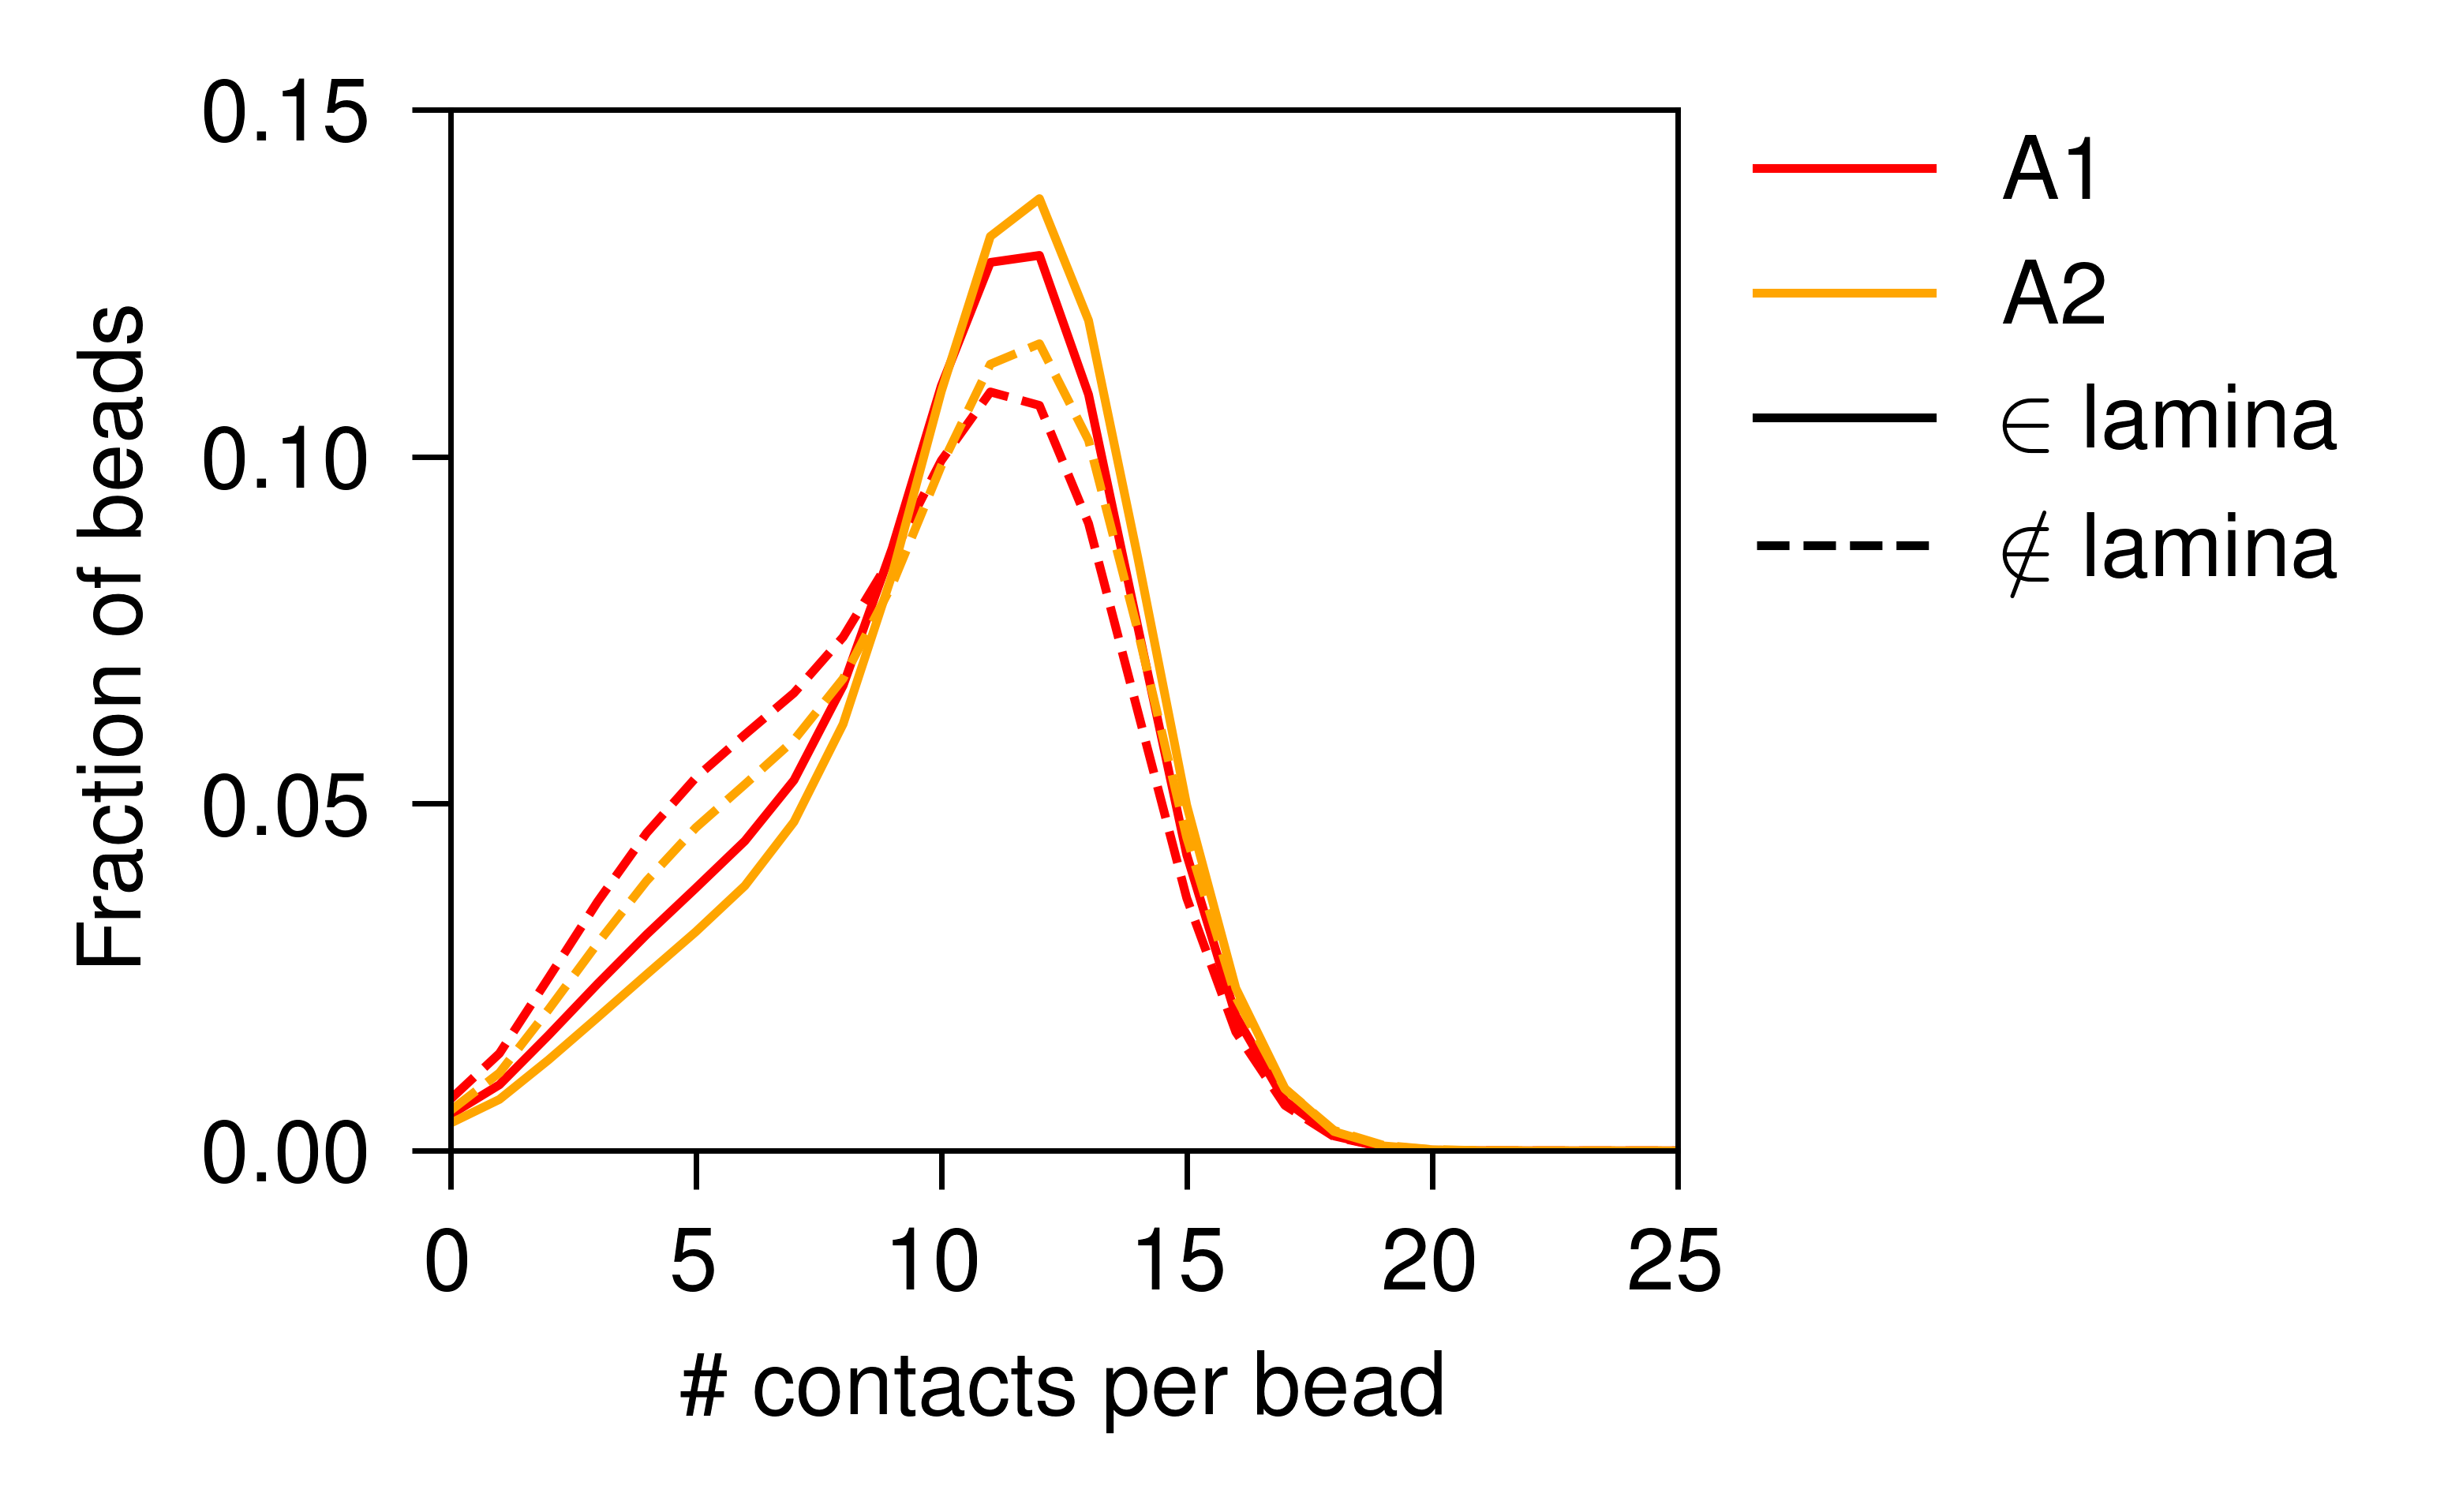

In [34]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(3.0, 1.8),
    layout="constrained",
    sharex=True,
    sharey=True,
)

colors = {
    "A1": "red",
    "A2": "orange",
}
line_style = {
    "complete": "-",
    "nucleolus": "--",
}

bins = np.arange(0, 27 + 1, 1)
for i_idx, label in enumerate(["A1", "A2"]):

    for condition in conditions:
        data_hist = total_contacts[condition][
            :, :, subcompartments == label
        ].ravel()

        counts, bins = np.histogram(
            data_hist,
            bins=bins,
            density=False,
            weights=np.ones_like(data_hist) / data_hist.size,
        )

        ax.plot(
            bins[:-1],
            counts,
            label=title[condition],
            color=colors[label],
            linestyle=line_style[condition],
        )
    ax.set_xlabel(r"\# contacts per bead")
    ax.set_xticks([0, 5, 10, 15, 20, 25])
    ax.set_xlim(bins[0], 25)
    ax.set_ylim(0, 0.15)
ax.set_ylabel("Fraction of beads")
legend_handles = [
    Line2D([0], [0], color="red", linewidth=0.8, linestyle="-", label="A1"),
    Line2D([0], [0], color="orange", linewidth=0.8, linestyle="-", label="A2"),
    Line2D([0], [0], color="black", linewidth=0.8, linestyle="-", label=r"$\in$ lamina"),
    Line2D([0], [0], color="black", linewidth=0.8, linestyle="--", label=r"$\notin$ lamina"),
]
ax.legend(handles=legend_handles, frameon=False, loc="upper left", bbox_to_anchor=(1, 1.05))

#### contacts between patches

In [ ]:
df_patches = pandas.read_pickle("../../1_inputs/chr1_patches.pkl")

In [ ]:
total_patch_contacts = {
    condition: contacts[condition]["num_contacts_per_patch"].sum(
        axis=3
    )
    for condition in conditions
}

In [ ]:
total_patch_contacts["complete"].min(), total_patch_contacts[
    "complete"
].max()

In [ ]:
total_patch_contacts["nucleolus"].min(), total_patch_contacts[
    "nucleolus"
].max()

In [ ]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(5.0, 1.8),
    layout="constrained",
    sharex=True,
    sharey=True,
)

bins = np.arange(0, 116 + 1, 1)
for i_idx, label in enumerate(["A", "B", "NA"]):

    for condition in conditions:
        data_hist = total_patch_contacts[condition][
            :, :, df_patches["compartment"] == label
        ].ravel()

        counts, bins = np.histogram(
            data_hist,
            bins=bins,
            density=False,
            weights=np.ones_like(data_hist) / data_hist.size,
        )

        ax[i_idx].plot(
            bins[:-1],
            counts,
            label=title[condition],
            color=color_palette[condition],
        )

    ax[i_idx].set_title(f"{label}", fontsize=8)
    ax[i_idx].set_xlabel(r"\# patches in contact")
    # ax[i_idx].set_xticks([0, 5, 10, 15, 20, 25])
    ax[i_idx].set_xlim(bins[0], 25)
    # ax[i_idx].set_ylim(0, 0.15)
ax[0].set_ylabel("Fraction of beads")
ax[-1].legend(
    frameon=False, loc="upper left", bbox_to_anchor=(1, 1.05)
)

In [ ]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(3.5, 1.8),
    layout="constrained",
    sharex=True,
    sharey=True,
)

bins = np.arange(0, 116 + 1, 1)
for i_idx, label in enumerate(["A", "B"]):

    for condition in conditions:
        data_hist = contacts[condition]["num_contacts_per_patch"][
            :, :, df_patches["compartment"] == label, i_idx
        ].ravel()

        counts, bins = np.histogram(
            data_hist,
            bins=bins,
            density=False,
            weights=np.ones_like(data_hist) / data_hist.size,
        )

        ax[i_idx].plot(
            bins[:-1],
            counts,
            label=title[condition],
            color=color_palette[condition],
        )

    ax[i_idx].set_title(f"{label}-{label}", fontsize=8)
    ax[i_idx].set_xlabel(r"\# patches in contact")
    # ax[i_idx].set_xticks([0, 5, 10, 15, 20, 25])
    ax[i_idx].set_xlim(bins[0], 15)
    # ax[i_idx].set_ylim(0, 0.15)
ax[0].set_ylabel("Fraction of beads")
ax[-1].legend(
    frameon=False, loc="upper left", bbox_to_anchor=(1, 1.05)
)

#### bead dynamics

In [45]:
annotations

array(['B', 'B', 'B', ..., 'A', 'A', 'A'], dtype=object)

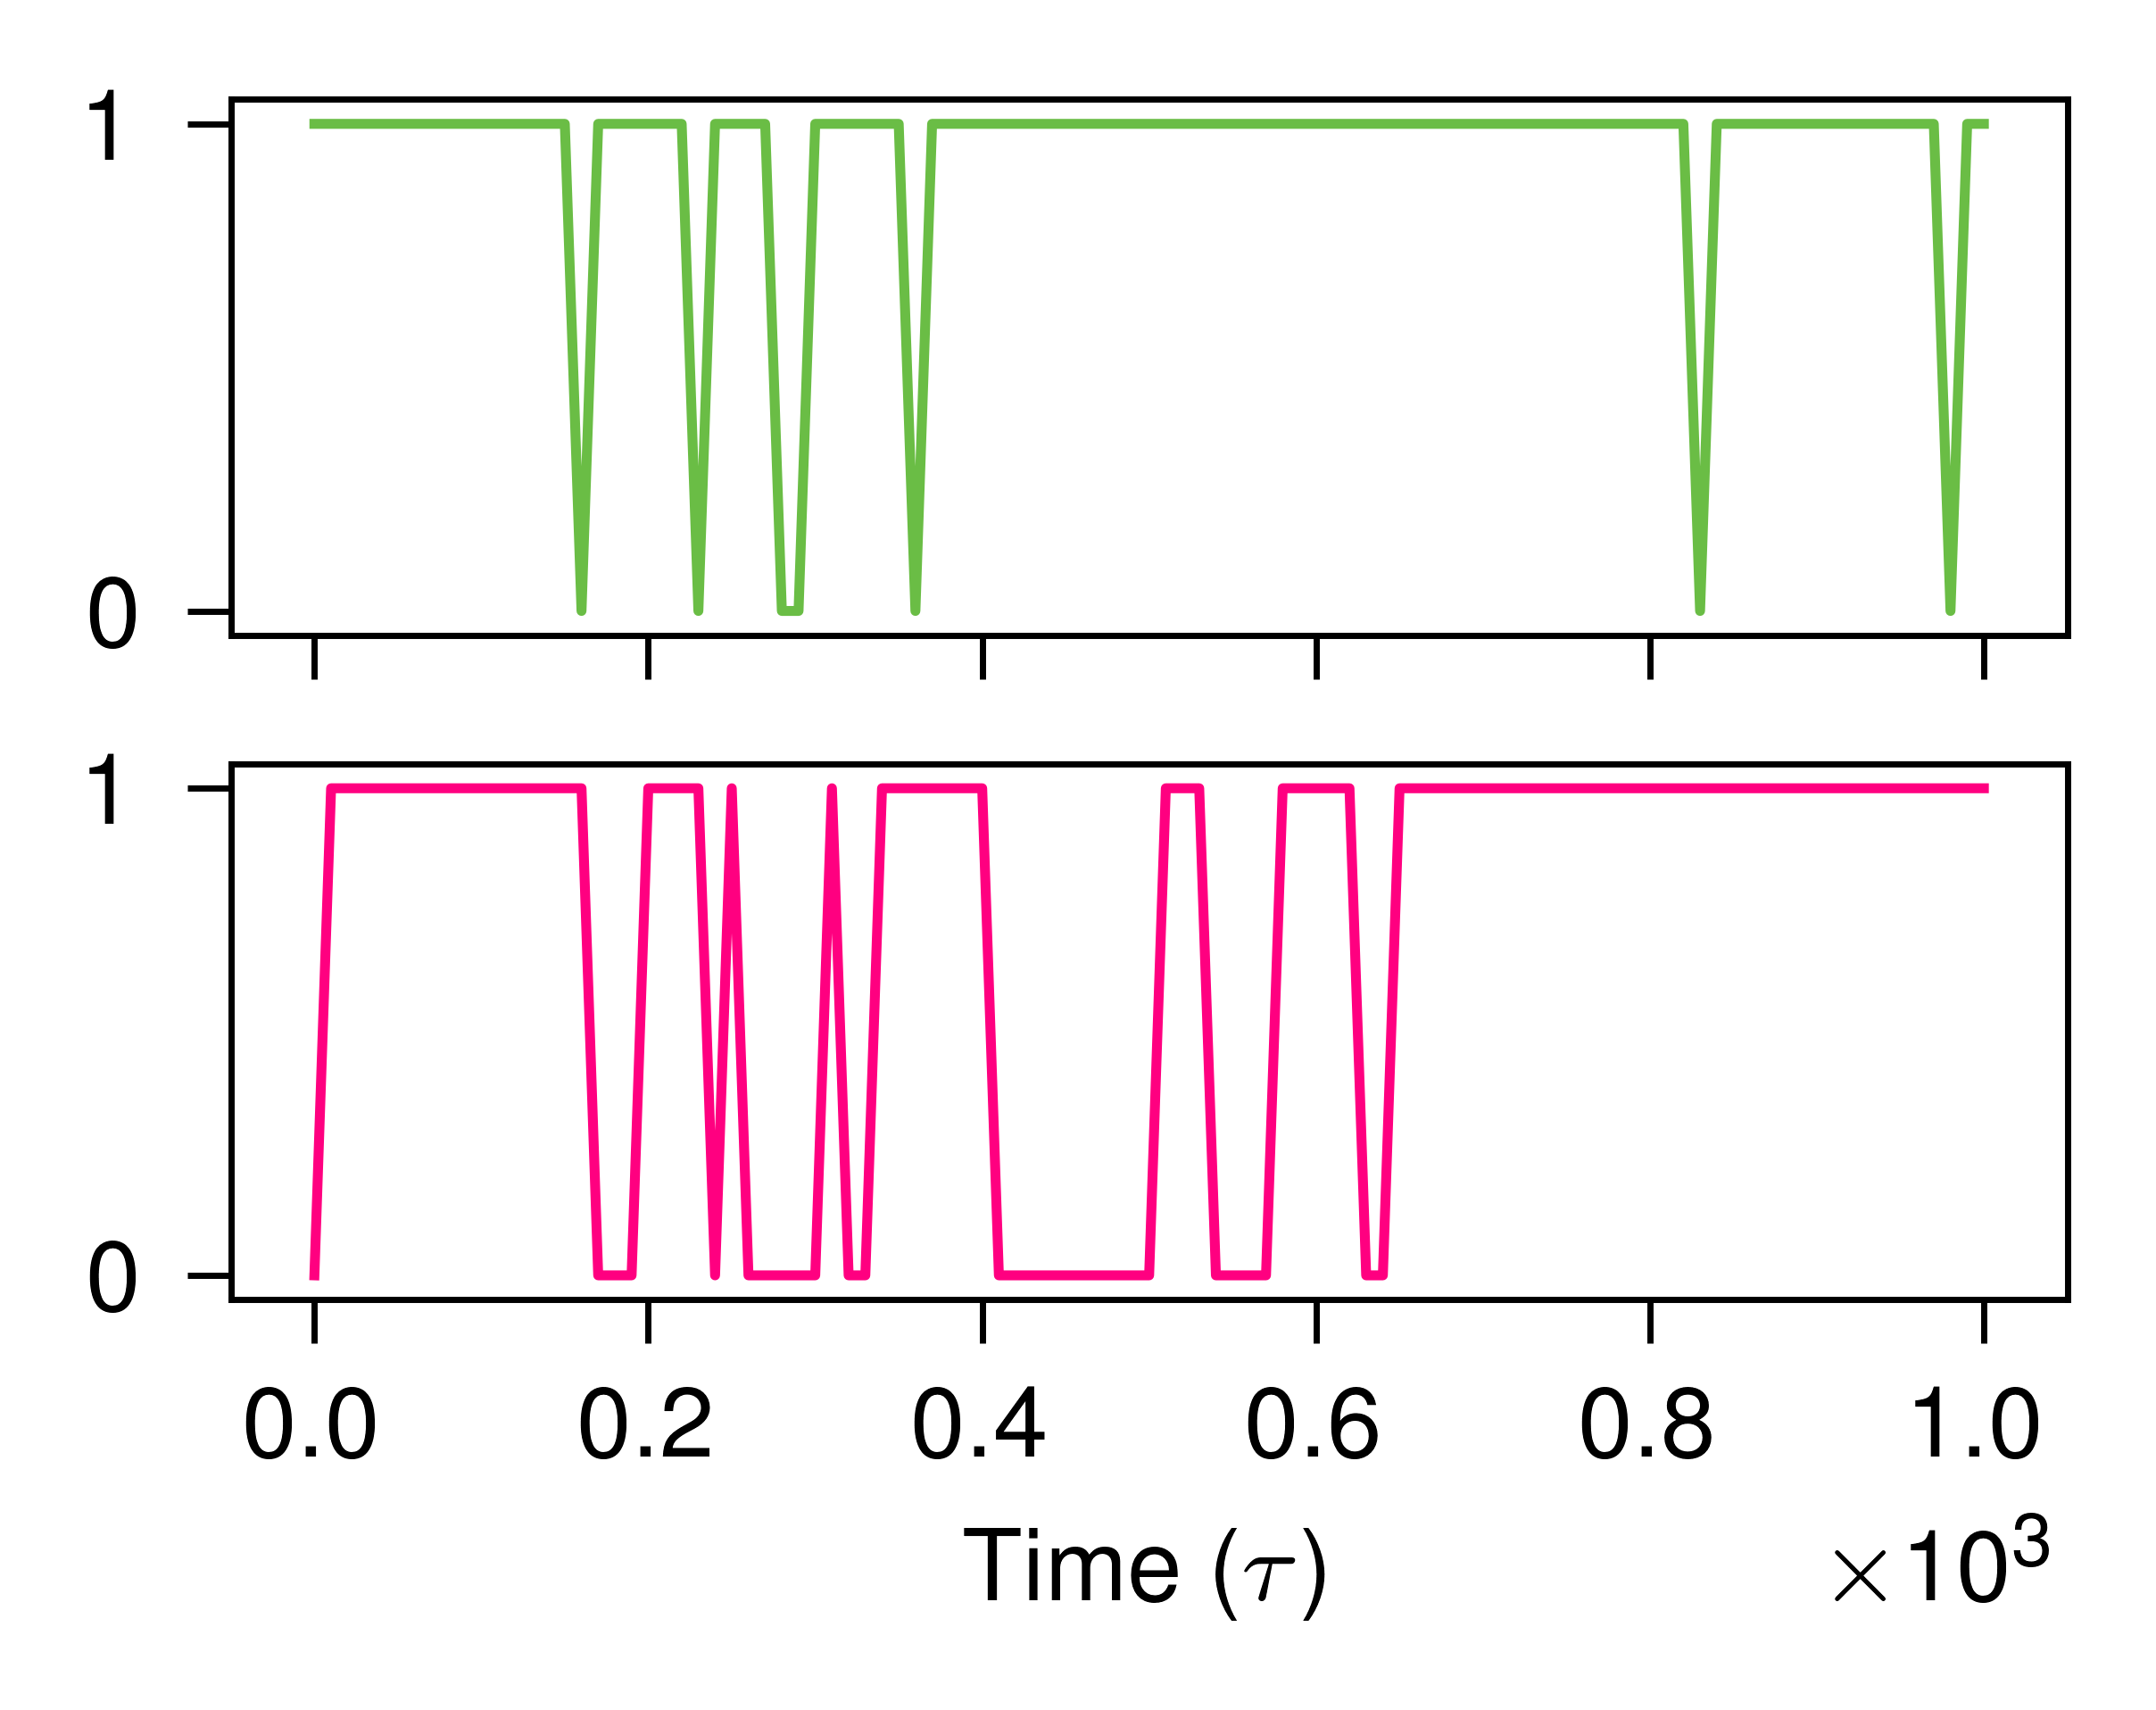

In [76]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(2.3, 1.8),
    sharex=True,
    sharey=True,
    layout="constrained",
)

time = np.arange(0, 10_000) * 1e3 * 0.01  # tau
time_slice = slice(550, 651, 1)

for idx, condition in enumerate(conditions):
    ax[idx].plot(
        np.arange(len(time[time_slice])) * 1e3 * 0.01,
        contacts[condition]["num_contacts_per_bead"][0, time_slice, 3977 - 1, 0] > 0,
        color=color_palette[condition],
        label=title[condition],
    )
    # ax[idx].set_ylabel(r"\# contacts with A beads")

# fig.supylabel(r"Time ($\tau$)")

ax[idx].set_xlabel(r"Time ($\tau$)")
formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax[idx].xaxis.set_major_formatter(formatter)

In [38]:
def contact_durations(x):
    """
    Parameters
    ----------
    x : array-like, shape (Ntime,) or (Nreplicas, Ntime)
        Binary trajectories: 0 = no contact, 1 = contact.

    Returns
    -------
    t_on : np.ndarray
        All consecutive 1-run lengths across all replicas.
    t_off : np.ndarray
        All consecutive 0-run lengths across all replicas.
    """
    x = np.asarray(x, dtype=np.int8)

    if x.ndim == 1:
        x = x[None, :]

    t_on_all = []
    t_off_all = []

    for row in x:
        if row.size == 0:
            continue

        changes = np.flatnonzero(np.diff(row)) + 1
        boundaries = np.r_[0, changes, row.size]

        run_lengths = np.diff(boundaries)
        run_values = row[boundaries[:-1]]

        t_on_all.append(run_lengths[run_values == 1])
        t_off_all.append(run_lengths[run_values == 0])

    t_on = (
        np.concatenate(t_on_all)
        if t_on_all
        else np.array([], dtype=int)
    )
    t_off = (
        np.concatenate(t_off_all)
        if t_off_all
        else np.array([], dtype=int)
    )

    return t_on, t_off

for AA contacts

In [39]:
contacts[condition]["num_contacts_per_bead"].shape

(32, 10000, 4980, 3)

In [40]:
tracks_AA = {
    condition: (
        contacts[condition]["num_contacts_per_bead"][
            :, ::10, annotations == "A", 0
        ]
        > 0
    )
    .astype(int)
    .reshape(-1, 1000)
    for condition in conditions
}

In [41]:
tracks_AA["complete"].shape

(67552, 1000)

In [42]:
t_on_AA = {condition: [] for condition in conditions}
t_off_AA = {condition: [] for condition in conditions}

for condition in conditions:
    t_on_AA[condition], t_off_AA[condition] = contact_durations(
        tracks_AA[condition]
    )

Text(0.5, 0.98, 'AA')

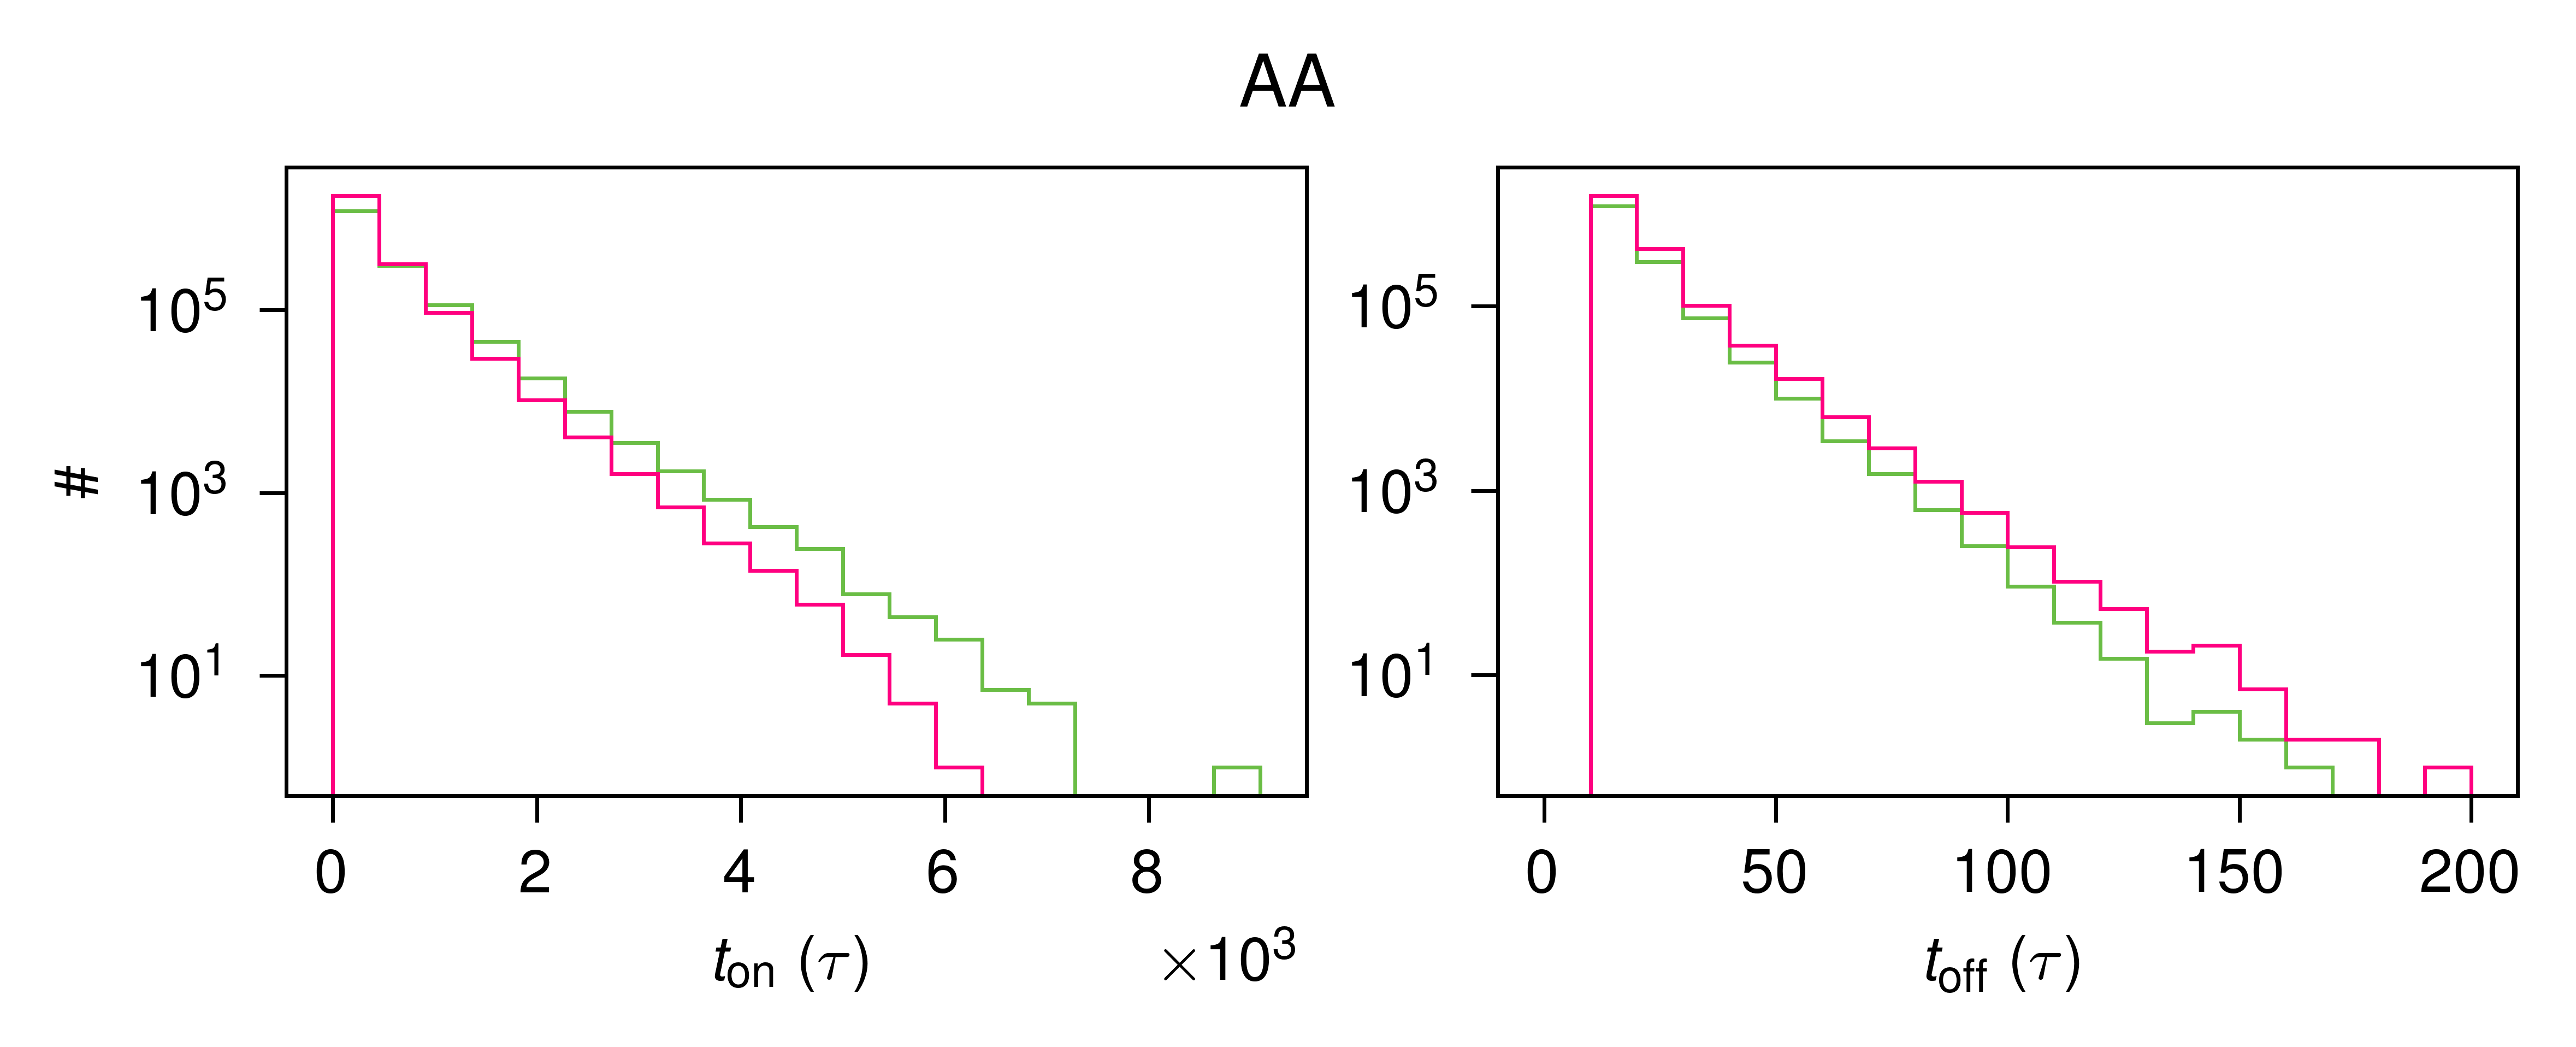

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(4.6, 1.8), layout="constrained")

t_on_AA_bins = np.linspace(
    0, np.max([np.max(x) for x in t_on_AA.values()]), 21
)
t_off_AA_bins = np.linspace(
    0, np.max([np.max(x) for x in t_off_AA.values()]), 21
)

for condition in conditions:
    ax[0].hist(
        np.array(t_on_AA[condition]) * 10,
        bins=t_on_AA_bins * 10,
        color=color_palette[condition],
        label=title[condition],
        # density=True,
        histtype="step",
    )
    ax[1].hist(
        np.array(t_off_AA[condition]) * 10,
        bins=t_off_AA_bins * 10,
        color=color_palette[condition],
        label=title[condition],
        # density=True,
        histtype="step",
    )

ax[0].set_xlabel(r"$t_\mathrm{on}~(\tau)$")
ax[1].set_xlabel(r"$t_\mathrm{off}~(\tau)$")

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 3))
ax[0].xaxis.set_major_formatter(formatter)

# formatter = mpl.ticker.ScalarFormatter(useMathText=True)
# formatter.set_scientific(True)
# formatter.set_powerlimits((0, 0))
# ax[1].xaxis.set_major_formatter(formatter)
# ax[1].set_xscale("log")

ax[0].set_ylabel("\#")

ax[0].set_yscale("log")
ax[1].set_yscale("log")

fig.suptitle("AA")

In [ ]:
tracks_BB = {
    condition: (
        contacts[condition]["num_contacts_per_bead"][
            :, ::10, annotations == "B", 1
        ]
        > 0
    )
    .astype(int)
    .reshape(-1, 1000)
    for condition in conditions
}

In [ ]:
tracks_BB["complete"].shape

In [ ]:
t_on_BB = {condition: [] for condition in conditions}
t_off_BB = {condition: [] for condition in conditions}

for condition in conditions:
    t_on_BB[condition], t_off_BB[condition] = contact_durations(
        tracks_BB[condition]
    )

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(4.6, 1.8), layout="constrained")

t_on_BB_bins = np.linspace(
    0, np.max([np.max(x) for x in t_on_BB.values()]), 21
)
t_off_BB_bins = np.linspace(
    0, np.max([np.max(x) for x in t_off_BB.values()]), 21
)

for condition in conditions:
    ax[0].hist(
        np.array(t_on_BB[condition]) * 10,
        bins=t_on_BB_bins * 10,
        color=color_palette[condition],
        label=title[condition],
        # density=True,
        histtype="step",
    )
    ax[1].hist(
        np.array(t_off_BB[condition]) * 10,
        bins=t_off_BB_bins * 10,
        color=color_palette[condition],
        label=title[condition],
        # density=True,
        histtype="step",
    )

ax[0].set_xlabel(r"$t_\mathrm{on}~(\tau)$")
ax[1].set_xlabel(r"$t_\mathrm{off}~(\tau)$")

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 3))
ax[0].xaxis.set_major_formatter(formatter)

# formatter = mpl.ticker.ScalarFormatter(useMathText=True)
# formatter.set_scientific(True)
# formatter.set_powerlimits((0, 0))
# ax[1].xaxis.set_major_formatter(formatter)
# ax[1].set_xscale("log")
fig.suptitle("BB")
ax[0].set_ylabel("\#")

ax[0].set_yscale("log")
ax[1].set_yscale("log")

#### patch dynamics

In [ ]:
def contact_durations(x):
    """
    Parameters
    ----------
    x : array-like, shape (Ntime,) or (Nreplicas, Ntime)
        Binary trajectories: 0 = no contact, 1 = contact.

    Returns
    -------
    t_on : np.ndarray
        All consecutive 1-run lengths across all replicas.
    t_off : np.ndarray
        All consecutive 0-run lengths across all replicas.
    """
    x = np.asarray(x, dtype=np.int8)

    if x.ndim == 1:
        x = x[None, :]

    t_on_all = []
    t_off_all = []

    for row in x:
        if row.size == 0:
            continue

        changes = np.flatnonzero(np.diff(row)) + 1
        boundaries = np.r_[0, changes, row.size]

        run_lengths = np.diff(boundaries)
        run_values = row[boundaries[:-1]]

        t_on_all.append(run_lengths[run_values == 1])
        t_off_all.append(run_lengths[run_values == 0])

    t_on = (
        np.concatenate(t_on_all)
        if t_on_all
        else np.array([], dtype=int)
    )
    t_off = (
        np.concatenate(t_off_all)
        if t_off_all
        else np.array([], dtype=int)
    )

    return t_on, t_off

for AA contacts

In [ ]:
contacts[condition]["num_contacts_per_patch"].shape

In [ ]:
tracks_AA = {
    condition: (
        contacts[condition]["num_contacts_per_patch"][
            :, :, df_patches.compartment == "A", 0
        ]
        > 0
    )
    .astype(int)
    .reshape(-1, 1000)
    for condition in conditions
}

In [ ]:
tracks_AA["complete"].shape

In [ ]:
t_on_AA = {condition: [] for condition in conditions}
t_off_AA = {condition: [] for condition in conditions}

for condition in conditions:
    t_on_AA[condition], t_off_AA[condition] = contact_durations(
        tracks_AA[condition]
    )

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(4.6, 1.8), layout="constrained")

t_on_AA_bins = np.linspace(
    0, np.max([np.max(x) for x in t_on_AA.values()]), 16
)
t_off_AA_bins = np.linspace(
    0, np.max([np.max(x) for x in t_off_AA.values()]), 16
)

for condition in conditions:
    ax[0].hist(
        np.array(t_on_AA[condition]) * 10,
        bins=t_on_AA_bins * 10,
        color=color_palette[condition],
        label=title[condition],
        # density=True,
        histtype="step",
    )
    ax[1].hist(
        np.array(t_off_AA[condition]) * 10,
        bins=t_off_AA_bins * 10,
        color=color_palette[condition],
        label=title[condition],
        # density=True,
        histtype="step",
    )

ax[0].set_xlabel(r"$t_\mathrm{on}~(\tau)$")
ax[1].set_xlabel(r"$t_\mathrm{off}~(\tau)$")

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 3))
ax[0].xaxis.set_major_formatter(formatter)

# formatter = mpl.ticker.ScalarFormatter(useMathText=True)
# formatter.set_scientific(True)
# formatter.set_powerlimits((0, 0))
# ax[1].xaxis.set_major_formatter(formatter)
# ax[1].set_xscale("log")

ax[0].set_ylabel("\#")

ax[0].set_yscale("log")
ax[1].set_yscale("log")

fig.suptitle("AA")

In [ ]:
tracks_BB = {
    condition: (
        contacts[condition]["num_contacts_per_patch"][
            :, :, df_patches.compartment == "B", 1
        ]
        > 0
    )
    .astype(int)
    .reshape(-1, 1000)
    for condition in conditions
}

In [ ]:
tracks_BB["complete"].shape

In [ ]:
t_on_BB = {condition: [] for condition in conditions}
t_off_BB = {condition: [] for condition in conditions}

for condition in conditions:
    t_on_BB[condition], t_off_BB[condition] = contact_durations(
        tracks_BB[condition]
    )

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(4.6, 1.8), layout="constrained")

t_on_BB_bins = np.linspace(
    0, np.max([np.max(x) for x in t_on_BB.values()]), 16
)
t_off_BB_bins = np.linspace(
    0, np.max([np.max(x) for x in t_off_BB.values()]), 16
)

for condition in conditions:
    ax[0].hist(
        np.array(t_on_BB[condition]) * 10,
        bins=t_on_BB_bins * 10,
        color=color_palette[condition],
        label=title[condition],
        # density=True,
        histtype="step",
    )
    ax[1].hist(
        np.array(t_off_BB[condition]) * 10,
        bins=t_off_BB_bins * 10,
        color=color_palette[condition],
        label=title[condition],
        # density=True,
        histtype="step",
    )

ax[0].set_xlabel(r"$t_\mathrm{on}~(\tau)$")
ax[1].set_xlabel(r"$t_\mathrm{off}~(\tau)$")

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 3))
ax[0].xaxis.set_major_formatter(formatter)

# formatter = mpl.ticker.ScalarFormatter(useMathText=True)
# formatter.set_scientific(True)
# formatter.set_powerlimits((0, 0))
# ax[1].xaxis.set_major_formatter(formatter)
# ax[1].set_xscale("log")
fig.suptitle("BB")
ax[0].set_ylabel("\#")

ax[0].set_yscale("log")
ax[1].set_yscale("log")